In [48]:
import numpy as np
import matplotlib.pyplot as plt
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

Using device: cuda
1. Generating Data...
   Full data shape: (1001, 2)
   Training data size: 800
   Test data size: 201

2. Creating Sequences and DataLoader...
   Created 780 training sequences.
   Input sequence shape (example batch): (64, 20, 2)
   Target shape (example batch): (64, 2)

3. Initializing Model, Loss, Optimizer...
   Model:
SimpleRNN(
  (rnn): RNN(2, 100, batch_first=True)
  (fc): Linear(in_features=100, out_features=2, bias=True)
)

4. Training RNN...
Starting Training...
Epoch 1/300, Loss: 0.301444
Epoch 21/300, Loss: 0.000011
Epoch 41/300, Loss: 0.000000
Epoch 61/300, Loss: 0.000000
Epoch 81/300, Loss: 0.000000
Epoch 101/300, Loss: 0.000000
Epoch 121/300, Loss: 0.000000
Epoch 141/300, Loss: 0.000000
Epoch 161/300, Loss: 0.000000
Epoch 181/300, Loss: 0.000000
Epoch 201/300, Loss: 0.000000
Epoch 221/300, Loss: 0.000011
Epoch 241/300, Loss: 0.000006
Epoch 261/300, Loss: 0.000004
Epoch 281/300, Loss: 0.000000
Epoch 300/300, Loss: 0.000000

Training finished in 9.34 sec

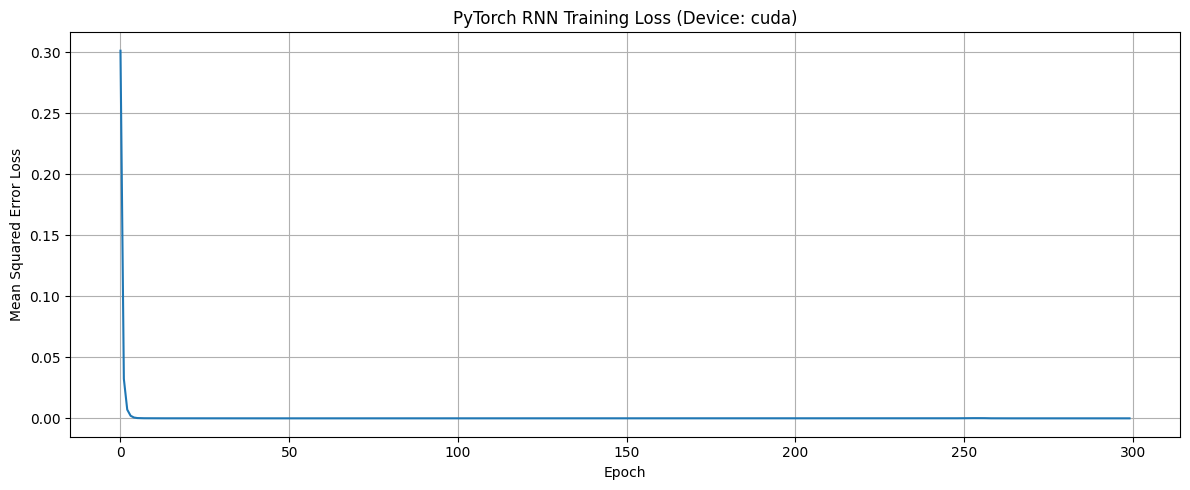

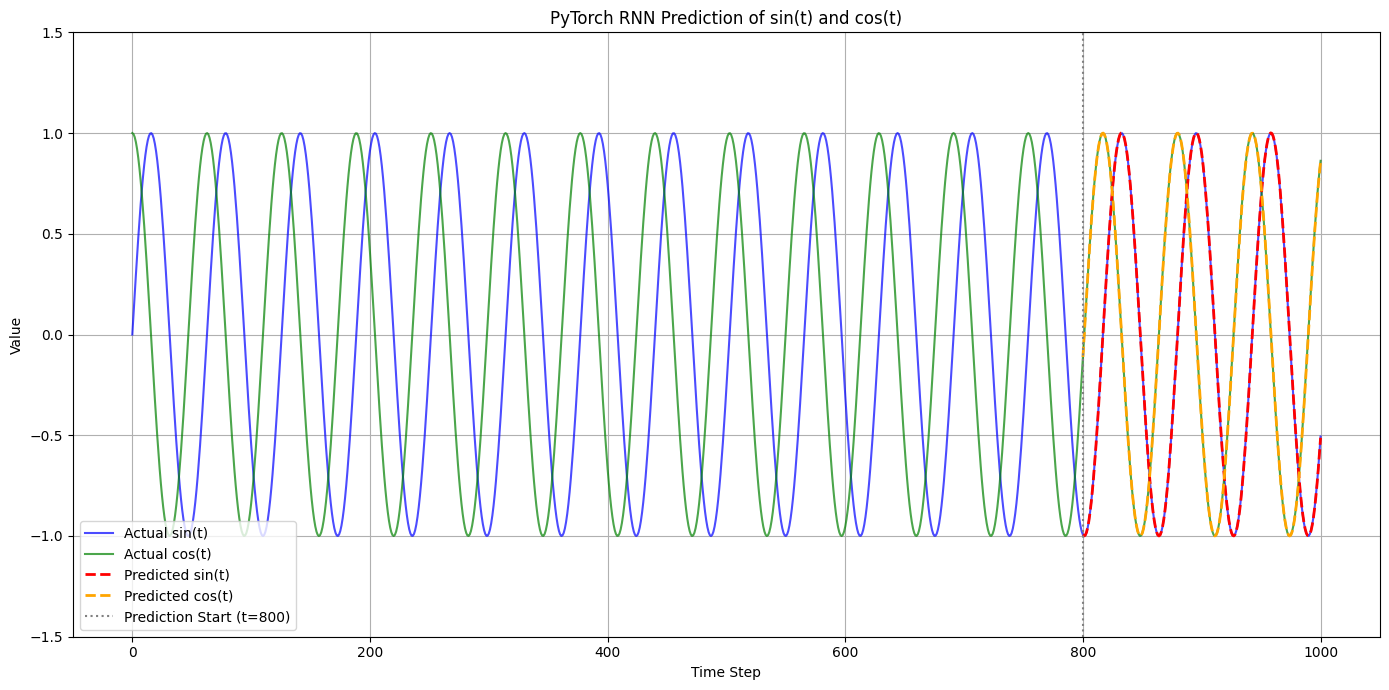

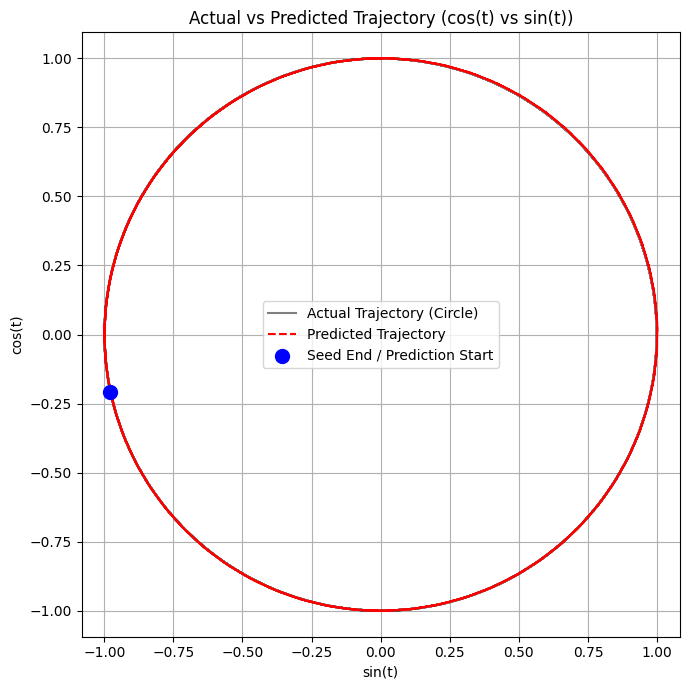

In [50]:
# --- Configuration ---
SEQUENCE_LENGTH = 20  # Length of input sequences for training
HIDDEN_SIZE = 100     # Number of neurons in the hidden layer
OUTPUT_SIZE = 2       # Predicting two values (sin, cos)
NUM_LAYERS = 1        # Number of RNN layers
LEARNING_RATE = 1e-3
EPOCHS = 300
BATCH_SIZE = 64
DATA_POINTS = 1000    # Total number of data points to generate
TRAIN_SPLIT = 0.8     # 80% for training, 20% for validation/testing
PLOT_EVERY = 20       # Plot loss every N epochs

# --- Device Configuration ---
# Check if CUDA (GPU) is available, otherwise use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- Data Generation
def generate_data(num_points):
    """Generates sine and cosine data."""
    t = np.linspace(0, num_points * 0.1, num_points + 1) # Generate time steps
    x_data = np.sin(t)
    y_data = np.cos(t)
    
    data = np.vstack((x_data, y_data)).T #shape (num_points + 1, 2)
    return data.astype(np.float32) # Ensure float32 for PyTorch

# --- Create Sequences for Training ---
def create_sequences(data, seq_length):
    """Creates input sequences and corresponding targets."""
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        # Input sequence: data from i to i + seq_length
        x = data[i:(i + seq_length)]
        # Target: the single next data point after the sequence
        y = data[i + seq_length]
        xs.append(x)
        ys.append(y)
    # Convert to numpy arrays before converting to tensors
    return np.array(xs), np.array(ys)

# --- PyTorch RNN Model Definition ---
class SimpleRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers):
        super(SimpleRNN, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        # Define the RNN layer. batch_first=True means input/output shape is (batch, seq, feature)
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        # Define the fully connected output layer
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x, h0=None):
        # x shape: (batch_size, seq_length, input_size)
        # h0 shape: (num_layers * num_directions, batch_size, hidden_size)

        # Initialize hidden state with zeros if not provided
        if h0 is None:
            # Determine batch size from input x
            batch_size = x.size(0)
            # Move hidden state initialization to the same device as input x
            h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(x.device)

        # Pass input and hidden state through RNN layer
        # out shape: (batch_size, seq_length, hidden_size) - contains output features for each time step
        # hn shape: (num_layers, batch_size, hidden_size) - contains the final hidden state
        out, hn = self.rnn(x, h0)

        # We only need the output from the *last* time step to predict the next value
        # Select the output of the last time step: out[:, -1, :]
        # Shape becomes: (batch_size, hidden_size)
        last_time_step_out = out[:, -1, :]

        # Pass the last time step's output through the fully connected layer
        # final_out shape: (batch_size, output_size)
        final_out = self.fc(last_time_step_out)

        return final_out, hn # Return final output and final hidden state

# --- Training Loop ---
def train_pytorch_rnn(model, train_loader, criterion, optimizer, epochs, device):
    """Trains the PyTorch RNN model."""
    model.train() # Set the model to training mode
    losses = []
    start_time = time.time()

    print("Starting Training...")
    for epoch in range(epochs):
        epoch_loss = 0
        num_batches = 0
        # Hidden state is typically reset per batch or managed carefully across batches.
        # For simplicity here, we let the forward pass initialize it per batch if needed,
        # or we could explicitly pass it if statefulness across batches is desired.

        for batch_idx, (inputs, targets) in enumerate(train_loader):
            # Move data to the configured device (GPU or CPU)
            inputs, targets = inputs.to(device), targets.to(device)

            # --- Forward Pass ---
            # Reset gradients for this batch
            optimizer.zero_grad()
            # Get model predictions. We don't need the hidden state during training loop here.
            outputs, _ = model(inputs)

            # --- Calculate Loss ---
            loss = criterion(outputs, targets)

            # --- Backward Pass and Optimization ---
            loss.backward() # Compute gradients
            optimizer.step() # Update model weights

            epoch_loss += loss.item() # Accumulate loss for the epoch
            num_batches += 1

        avg_epoch_loss = epoch_loss / num_batches if num_batches > 0 else 0
        losses.append(avg_epoch_loss)

        if epoch % PLOT_EVERY == 0 or epoch == epochs - 1:
            print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_epoch_loss:.6f}")

    end_time = time.time()
    print(f"\nTraining finished in {end_time - start_time:.2f} seconds.")
    return losses

# --- Prediction ---
def predict_pytorch(model, seed_sequence, predict_steps, device):
    """Predicts future values using the trained PyTorch model."""
    model.eval() # Set the model to evaluation mode
    predictions = []
    hidden = None # Start with no hidden state (model will initialize)

    # Convert seed sequence to tensor and move to device
    current_sequence_np = seed_sequence.copy() # Work with a copy

    with torch.no_grad(): # Disable gradient calculations for prediction
        # "Warm up" the hidden state using the seed sequence
        # Process the seed sequence except the last element to get the final hidden state
        seed_input = torch.from_numpy(current_sequence_np[:-1]).unsqueeze(0).to(device) # Add batch dimension (1, seq-1, input_size)
        _, hidden = model(seed_input, None) # Get the hidden state after processing the seed

        # Use the last actual point from the seed as the first input for prediction
        last_input_np = current_sequence_np[-1:] # Shape (1, input_size)
        last_input = torch.from_numpy(last_input_np).unsqueeze(0).to(device) # Shape (1, 1, input_size)

        # Generate predictions step-by-step
        for _ in range(predict_steps):
            # Get the prediction and the next hidden state
            # Input shape: (batch_size=1, seq_len=1, input_size)
            output, hidden = model(last_input, hidden)

            # Store the prediction
            predicted_val = output.squeeze(0).cpu().numpy() # Remove batch dim, move to CPU, convert to numpy
            predictions.append(predicted_val)

            # Use the prediction as the input for the next step
            # Ensure the input for the next step has the correct shape (1, 1, input_size)
            last_input = output.unsqueeze(1) # Add sequence length dimension back

    return np.array(predictions)


# --- Main Execution ---
if __name__ == "__main__":
    print("1. Generating Data...")
    full_data_np = generate_data(DATA_POINTS)
    input_size = full_data_np.shape[1] # Should be 2

    # Split data
    split_idx = int(len(full_data_np) * TRAIN_SPLIT)
    train_data_np = full_data_np[:split_idx]
    test_data_np = full_data_np[split_idx:]

    print(f"   Full data shape: {full_data_np.shape}")
    print(f"   Training data size: {len(train_data_np)}")
    print(f"   Test data size: {len(test_data_np)}")

    print("\n2. Creating Sequences and DataLoader...")
    X_train_np, y_train_np = create_sequences(train_data_np, SEQUENCE_LENGTH)

    # Convert numpy arrays to PyTorch tensors
    X_train = torch.from_numpy(X_train_np)
    y_train = torch.from_numpy(y_train_np)

    # Create TensorDataset and DataLoader
    train_dataset = TensorDataset(X_train, y_train)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True) # Shuffle for training

    print(f"   Created {len(X_train)} training sequences.")
    print(f"   Input sequence shape (example batch): ({BATCH_SIZE}, {SEQUENCE_LENGTH}, {input_size})")
    print(f"   Target shape (example batch): ({BATCH_SIZE}, {OUTPUT_SIZE})")


    print("\n3. Initializing Model, Loss, Optimizer...")
    # Instantiate the model
    model = SimpleRNN(input_size, HIDDEN_SIZE, OUTPUT_SIZE, NUM_LAYERS)
    model.to(device) # Move model to the selected device (GPU/CPU)

    # Define loss function (Mean Squared Error)
    criterion = nn.MSELoss()

    # Define optimizer (Adam is often a good choice)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    print(f"   Model:\n{model}")

    print("\n4. Training RNN...")
    training_losses = train_pytorch_rnn(model, train_loader, criterion, optimizer, EPOCHS, device)

    print("\n5. Predicting...")
    # Use the last part of the *full* data as the seed sequence
    # Ensure the seed length matches SEQUENCE_LENGTH used for creating sequences
    seed_idx_start = split_idx - SEQUENCE_LENGTH
    seed_idx_end = split_idx
    seed_np = full_data_np[seed_idx_start:seed_idx_end] # Seed shape: (SEQUENCE_LENGTH, input_size)

    num_predict_steps = len(test_data_np) # Predict as many steps as we have test data
    predicted_values_np = predict_pytorch(model, seed_np, num_predict_steps, device)

    print(f"   Predicted {num_predict_steps} steps.")
    print(f"   Seed shape: {seed_np.shape}")
    print(f"   Prediction output shape: {predicted_values_np.shape}")


    print("\n6. Plotting Results...")
    # --- Plot Training Loss ---
    plt.figure(figsize=(12, 5))
    plt.plot(training_losses)
    plt.title(f"PyTorch RNN Training Loss (Device: {device.type})")
    plt.xlabel("Epoch")
    plt.ylabel("Mean Squared Error Loss")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # --- Plot Predictions vs Actual ---
    # Time axes need to align with the actual data points being predicted
    time_axis_pred = np.arange(split_idx, split_idx + num_predict_steps)
    time_axis_full = np.arange(len(full_data_np))

    plt.figure(figsize=(14, 7))

    # Plot Ground Truth (Full data)
    plt.plot(time_axis_full, full_data_np[:, 0], 'b-', label='Actual sin(t)', alpha=0.7)
    plt.plot(time_axis_full, full_data_np[:, 1], 'g-', label='Actual cos(t)', alpha=0.7)

    # Plot Predictions
    if len(predicted_values_np) > 0:
        plt.plot(time_axis_pred, predicted_values_np[:, 0], 'r--', label='Predicted sin(t)', linewidth=2)
        plt.plot(time_axis_pred, predicted_values_np[:, 1], 'orange', linestyle='--', label='Predicted cos(t)', linewidth=2)

    # Add a vertical line indicating the start of prediction
    plt.axvline(x=split_idx, color='gray', linestyle=':', label=f'Prediction Start (t={split_idx})')

    plt.title("PyTorch RNN Prediction of sin(t) and cos(t)")
    plt.xlabel("Time Step")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True)
    plt.ylim(-1.5, 1.5) # Set y-axis limits for sin/cos
    plt.tight_layout()
    plt.show()

    # --- Plot Trajectory (Phase Plot) ---
    plt.figure(figsize=(7, 7))
    # Plot actual trajectory
    plt.plot(full_data_np[:, 0], full_data_np[:, 1], 'k-', label='Actual Trajectory (Circle)', alpha=0.5)
    # Plot predicted trajectory
    if len(predicted_values_np) > 0:
        plt.plot(predicted_values_np[:, 0], predicted_values_np[:, 1], 'r--', label='Predicted Trajectory')
    # Mark the starting point of the prediction
    plt.scatter(seed_np[-1, 0], seed_np[-1, 1], c='blue', marker='o', s=100, label='Seed End / Prediction Start', zorder=5)
    plt.title("Actual vs Predicted Trajectory (cos(t) vs sin(t))")
    plt.xlabel("sin(t)")
    plt.ylabel("cos(t)")
    plt.legend()
    plt.grid(True)
    plt.axis('equal') # Make axes equal to show the circle properly
    plt.tight_layout()
    plt.show()